# imports & setup

In [1]:
from pathlib import Path

import polars as pl

# muutils
import muutils.tensor_info
from muutils.dbg import dbg_tensor

# attention-motifs
from attention_motifs.features.analysis import (
	DistanceTensorResult,
)
from attention_motifs.attnpedia.attnpedia import AttentionPedia

In [2]:
# magic autoreload
%load_ext autoreload
%autoreload 2

In [3]:
# numbers of rows to display
pl.Config.set_tbl_rows(10)
# colored muutils tensor info
muutils.tensor_info.DEFAULT_SETTINGS["colored"] = True
# base path
PATH_BASE: Path = Path("../data/features/")

# load data

In [4]:
DF_PCA: pl.DataFrame = pl.read_ndjson(PATH_BASE / "pca.jsonl")

# distances between heads

In [5]:
HEAD_DISTS: DistanceTensorResult = DistanceTensorResult.build_distance_tensor(
	DF_PCA,
	feature_prefix="pc.",
)
dbg_tensor(HEAD_DISTS.distances)
dbg_tensor(HEAD_DISTS.mean_dists)
HEAD_DISTS.save(PATH_BASE / "head_dists.zanj")

prompts: 100%|██████████| 128/128 [00:34<00:00,  3.67it/s]
[ <ipykernel>:5 ] HEAD_DISTS.distances: μ=10.51 σ=4.93 x̃=9.62 R=[0.00,43.65] ℙ=|▂█▃    | shape=(1520,1520,128) dtype=float64
[ <ipykernel>:6 ] HEAD_DISTS.mean_dists: μ=10.51 σ=4.48 x̃=9.62 R=[0.00,34.04] ℙ=| █▅▁   | shape=(1520,1520) dtype=float64


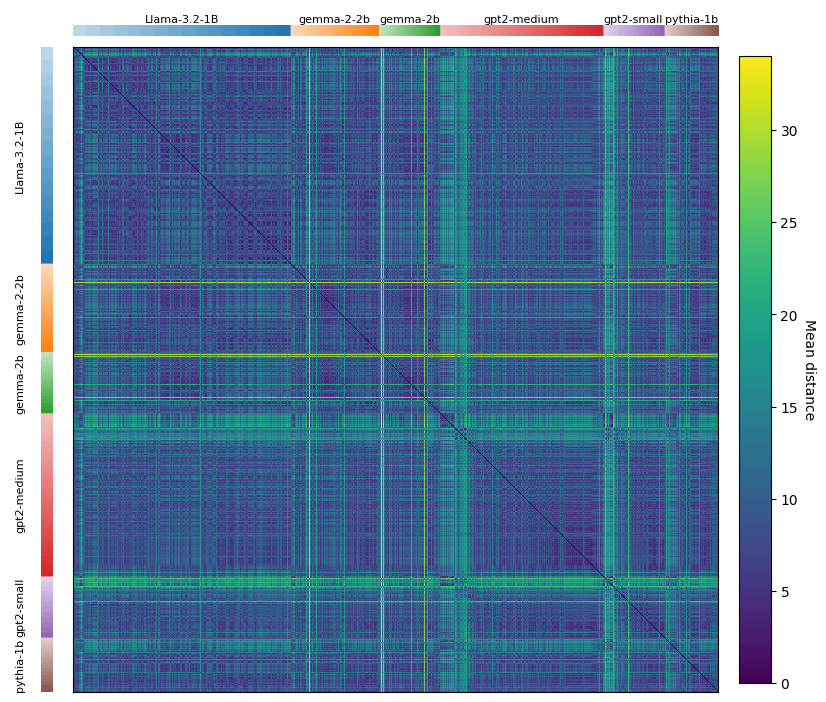

In [6]:
fig = HEAD_DISTS.plot_heatmap(show=False)
fig.savefig(
	"figures/head-dists-heatmap.pdf",
	bbox_inches="tight",
	pad_inches=0.1,
)

# attentionpedia

In [7]:
ATTENTIONPEDIA: AttentionPedia = AttentionPedia()

In [8]:
HEAD_DISTS.get_closest_heads("gpt2-small:L5:H5", n_closest=10)
# 'gpt2-medium:L5:H8

# for k in HEAD_DISTS.cls_values:
# 	plt.plot(
# 		[
# 			x[1]
# 			for x in HEAD_DISTS.get_closest_heads(k, n_closest=50)[1:]
# 		],
# 		alpha=0.05,
# 		color="black",
# 	)

# plt.show()

[('gpt2-small:L5:H5', 0.0),
 ('gpt2-medium:L9:H3', 2.855348386936258),
 ('gpt2-medium:L5:H8', 3.0252661140315067),
 ('gemma-2-2b:L6:H2', 3.233932322840425),
 ('gemma-2b:L5:H5', 3.7453987110931353),
 ('pythia-1b:L5:H7', 3.824225798472447),
 ('gpt2-medium:L6:H11', 3.885619831603462),
 ('gpt2-medium:L12:H0', 4.1188458341373035),
 ('gpt2-medium:L18:H13', 4.177911251550061),
 ('gpt2-small:L3:H0', 4.185567642578844)]

In [9]:
# HEAD_DISTS.plot_hists(n_samples=64)